# Step 2-2: 유저/아이템 활동 패턴 분석

## 목표
- 유저별 첫 활동 시점 분포, 활동 기간 분포, 활성도 추이
- 아이템별 최초 상호작용 시점 분포, 활성 기간 분포, 활성도 추이

## 데이터 특성 고려사항
- **Left Truncation**: 2005-04-11 이전 데이터 없음
- **Right Censoring**: 2015-03-31 이후 데이터 없음

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/train/'
print("Setup complete.")

Setup complete.


In [2]:
ratings = pd.read_csv(os.path.join(DATA_PATH, 'train_ratings.csv'))
ratings['datetime'] = pd.to_datetime(ratings['time'], unit='s')
ratings['year_month'] = ratings['datetime'].dt.to_period('M')

DATA_START = ratings['datetime'].min()
DATA_END = ratings['datetime'].max()
OBSERVATION_CUTOFF = DATA_END - pd.Timedelta(days=730)

print(f"데이터 범위: {DATA_START} ~ {DATA_END}")
print(f"Right Censoring 필터 기준: {OBSERVATION_CUTOFF.date()}")

데이터 범위: 2005-04-11 11:56:25 ~ 2015-03-31 05:50:52
Right Censoring 필터 기준: 2013-03-31


---
## 1. 유저 분석
### 1-1. 유저 첫 활동 시점 분포

In [3]:
user_activity = ratings.groupby('user')['datetime'].agg(['min', 'max'])
user_activity.columns = ['first_activity', 'last_activity']
user_activity['activity_duration_days'] = (user_activity['last_activity'] - user_activity['first_activity']).dt.days
user_activity['first_year_month'] = user_activity['first_activity'].dt.to_period('M')

print(f"총 유저 수: {len(user_activity):,}")

총 유저 수: 31,360


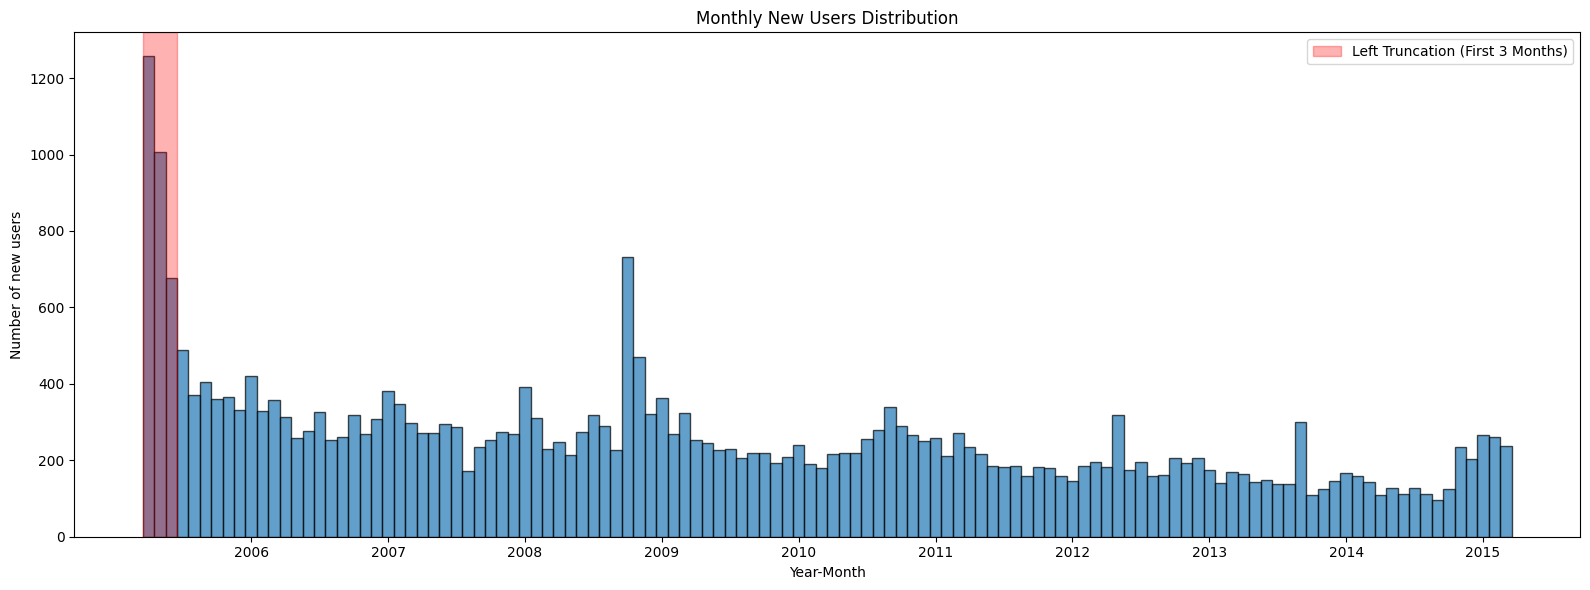

첫 3개월 신규 유저: 2,941명 (9.4%)


In [4]:
new_users_monthly = user_activity['first_year_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(new_users_monthly))
ax.bar(x, new_users_monthly.values, edgecolor='black', alpha=0.7, width=1.0)
ax.axvspan(-0.5, 2.5, alpha=0.3, color='red', label='Left Truncation (First 3 Months)')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of new users')
ax.set_title('Monthly New Users Distribution')
tick_positions = [i for i, ym in enumerate(new_users_monthly.index) if ym.month == 1]
tick_labels = [str(new_users_monthly.index[i].year) for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.legend()
plt.tight_layout()
plt.show()

print(f"첫 3개월 신규 유저: {new_users_monthly.head(3).sum():,}명 ({new_users_monthly.head(3).sum()/len(user_activity)*100:.1f}%)")

### 1-2. 유저 활동 기간 분포

In [5]:
user_activity_filtered = user_activity[user_activity['first_activity'] <= OBSERVATION_CUTOFF].copy()
duration_days = user_activity_filtered['activity_duration_days']

print(f"필터 후 유저: {len(user_activity_filtered):,}명")
print(f"평균: {duration_days.mean():.1f}일, 중앙값: {duration_days.median():.0f}일")

필터 후 유저: 27,459명
평균: 493.3일, 중앙값: 20일


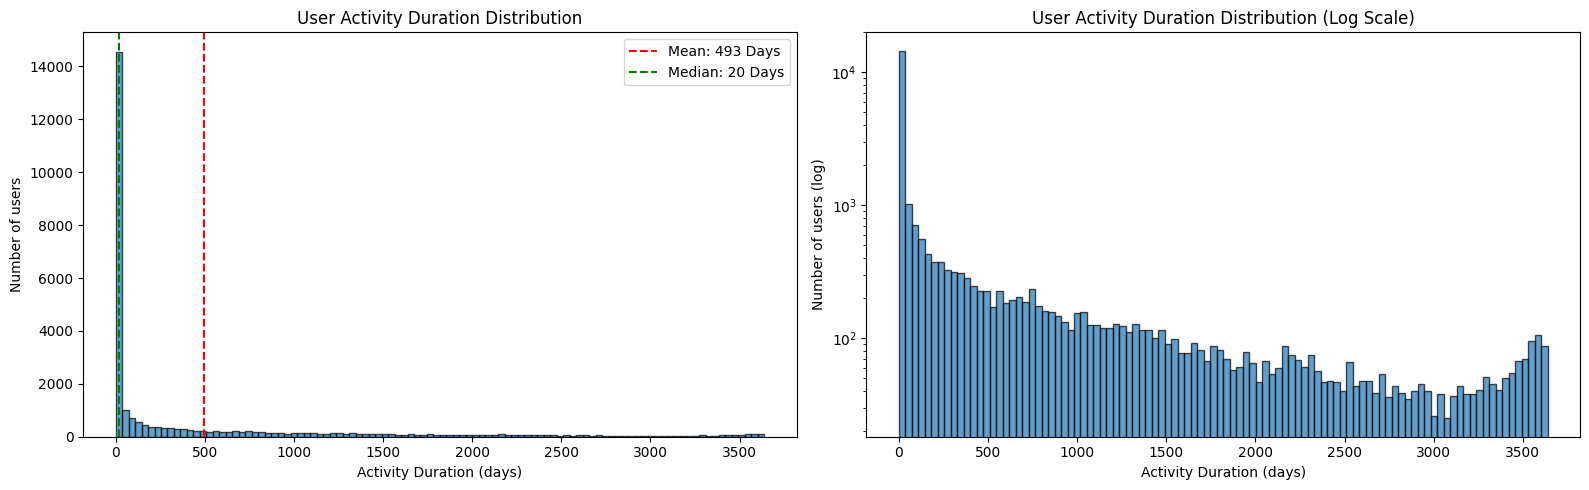

단일 세션 유저 (0일): 9,785명 (35.6%)
2년 이상 활동: 6,305명 (23.0%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(duration_days, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(duration_days.mean(), color='red', linestyle='--', label=f'Mean: {duration_days.mean():.0f} Days')
axes[0].axvline(duration_days.median(), color='green', linestyle='--', label=f'Median: {duration_days.median():.0f} Days')
axes[0].set_xlabel('Activity Duration (days)')
axes[0].set_ylabel('Number of users')
axes[0].set_title('User Activity Duration Distribution')
axes[0].legend()

axes[1].hist(duration_days, bins=100, edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_xlabel('Activity Duration (days)')
axes[1].set_ylabel('Number of users (log)')
axes[1].set_title('User Activity Duration Distribution (Log Scale)')
plt.tight_layout()
plt.show()

print(f"단일 세션 유저 (0일): {(duration_days == 0).sum():,}명 ({(duration_days == 0).sum()/len(duration_days)*100:.1f}%)")
print(f"2년 이상 활동: {(duration_days > 730).sum():,}명 ({(duration_days > 730).sum()/len(duration_days)*100:.1f}%)")

### 1-3. 유저 활성도 추이

In [7]:
user_active_months = ratings.groupby('user')['year_month'].apply(set).to_dict()
user_first_month = user_activity['first_year_month'].to_dict()

max_elapsed = 120
user_elapsed_stats = []

for elapsed in range(max_elapsed + 1):
    active, observable = 0, 0
    for user, first_month in user_first_month.items():
        target = first_month + elapsed
        if target <= DATA_END.to_period('M'):
            observable += 1
            if target in user_active_months[user]:
                active += 1
    if observable > 0:
        user_elapsed_stats.append({'elapsed_month': elapsed, 'active': active, 'observable': observable, 'rate': active/observable*100})

user_elapsed_df = pd.DataFrame(user_elapsed_stats)
print(user_elapsed_df.head(13))

    elapsed_month  active  observable        rate
0               0   31360       31360  100.000000
1               1    9994       31123   32.111300
2               2    6608       30861   21.412138
3               3    5460       30594   17.846637
4               4    4861       30391   15.994867
5               5    4396       30156   14.577530
6               6    4182       30030   13.926074
7               7    3937       29935   13.151829
8               8    3792       29822   12.715445
9               9    3557       29695   11.978448
10             10    3457       29583   11.685765
11             11    3371       29455   11.444576
12             12    3271       29345   11.146703


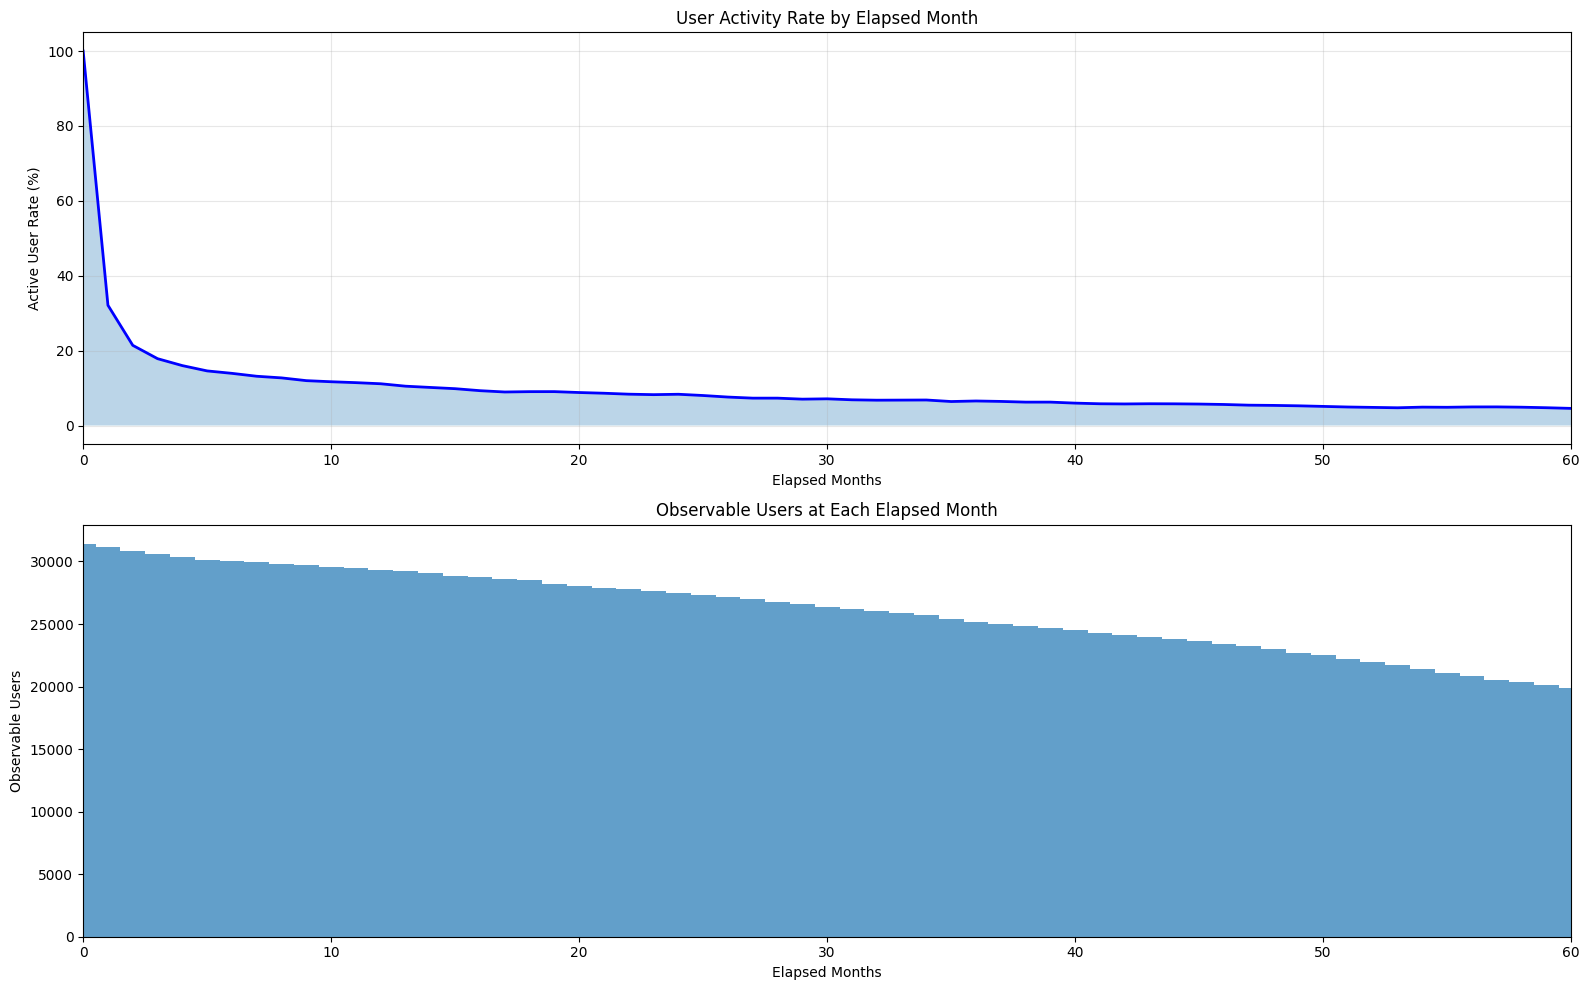

0개월: 100.0% (N=31,360.0)
1개월: 32.1% (N=31,123.0)
3개월: 17.8% (N=30,594.0)
6개월: 13.9% (N=30,030.0)
12개월: 11.1% (N=29,345.0)
24개월: 8.3% (N=27,463.0)
36개월: 6.5% (N=25,184.0)
48개월: 5.4% (N=22,972.0)


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].plot(user_elapsed_df['elapsed_month'], user_elapsed_df['rate'], linewidth=2, color='blue')
axes[0].fill_between(user_elapsed_df['elapsed_month'], user_elapsed_df['rate'], alpha=0.3)
axes[0].set_xlim(0, 60)
axes[0].set_xlabel('Elapsed Months')
axes[0].set_ylabel('Active User Rate (%)')
axes[0].set_title('User Activity Rate by Elapsed Month')
axes[0].grid(alpha=0.3)

axes[1].bar(user_elapsed_df['elapsed_month'], user_elapsed_df['observable'], alpha=0.7, width=1.0)
axes[1].set_xlim(0, 60)
axes[1].set_xlabel('Elapsed Months')
axes[1].set_ylabel('Observable Users')
axes[1].set_title('Observable Users at Each Elapsed Month')
plt.tight_layout()
plt.show()

for m in [0, 1, 3, 6, 12, 24, 36, 48]:
    if m < len(user_elapsed_df):
        r = user_elapsed_df[user_elapsed_df['elapsed_month']==m].iloc[0]
        print(f"{m}개월: {r['rate']:.1f}% (N={r['observable']:,})")

---
## 2. 아이템 분석
### 2-1. 아이템 최초 상호작용 시점 분포

In [9]:
item_activity = ratings.groupby('item')['datetime'].agg(['min', 'max'])
item_activity.columns = ['first_interaction', 'last_interaction']
item_activity['activity_duration_days'] = (item_activity['last_interaction'] - item_activity['first_interaction']).dt.days
item_activity['first_year_month'] = item_activity['first_interaction'].dt.to_period('M')

print(f"총 아이템 수: {len(item_activity):,}")

총 아이템 수: 6,807


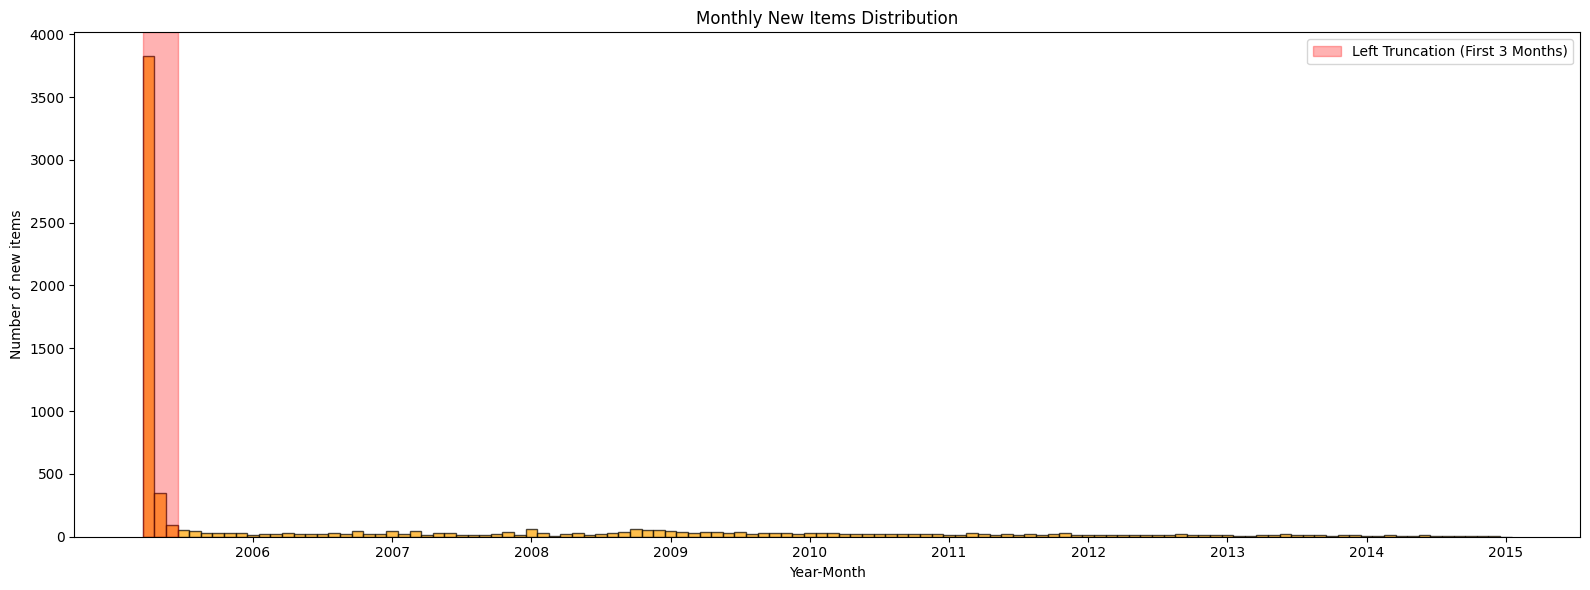

첫 3개월 신규 아이템: 4,263개 (62.6%)


In [10]:
new_items_monthly = item_activity['first_year_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(new_items_monthly))
ax.bar(x, new_items_monthly.values, edgecolor='black', alpha=0.7, width=1.0, color='orange')
ax.axvspan(-0.5, 2.5, alpha=0.3, color='red', label='Left Truncation (First 3 Months)')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of new items')
ax.set_title('Monthly New Items Distribution')
tick_positions = [i for i, ym in enumerate(new_items_monthly.index) if ym.month == 1]
tick_labels = [str(new_items_monthly.index[i].year) for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.legend()
plt.tight_layout()
plt.show()

print(f"첫 3개월 신규 아이템: {new_items_monthly.head(3).sum():,}개 ({new_items_monthly.head(3).sum()/len(item_activity)*100:.1f}%)")

### 2-2. 아이템 활성 기간 분포

In [11]:
item_activity_filtered = item_activity[item_activity['first_interaction'] <= OBSERVATION_CUTOFF].copy()
item_duration_days = item_activity_filtered['activity_duration_days']

print(f"필터 후 아이템: {len(item_activity_filtered):,}개")
print(f"평균: {item_duration_days.mean():.1f}일, 중앙값: {item_duration_days.median():.0f}일")

필터 후 아이템: 6,600개
평균: 3125.1일, 중앙값: 3580일


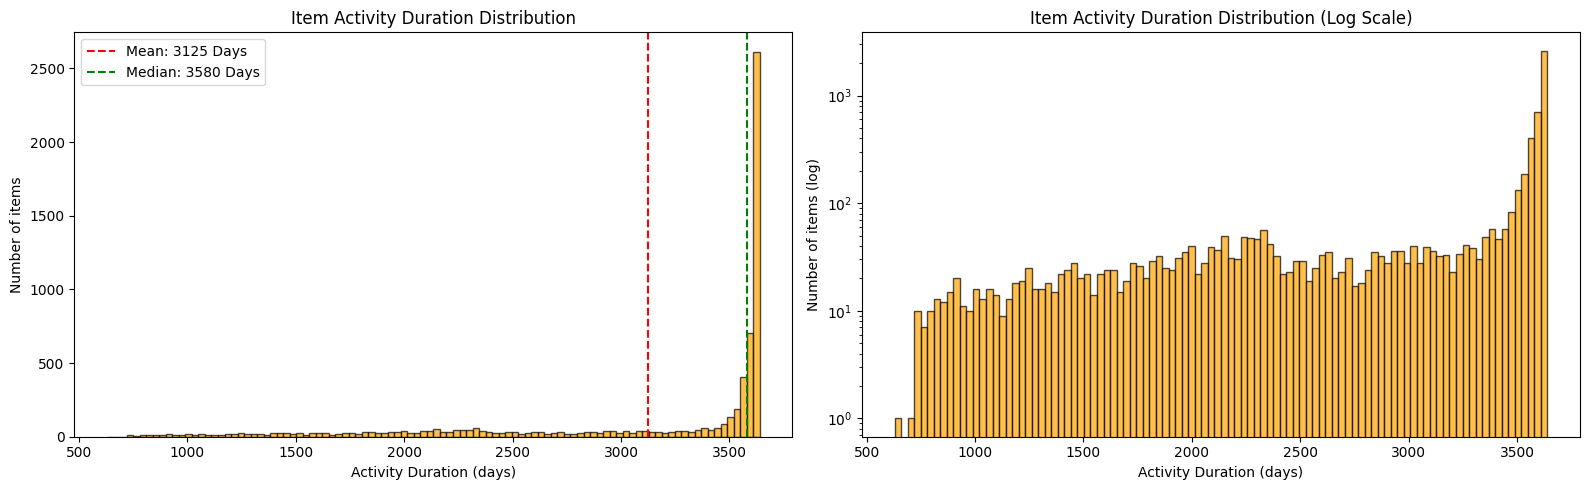

2년 이상 활성: 6,594개 (99.9%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(item_duration_days, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[0].axvline(item_duration_days.mean(), color='red', linestyle='--', label=f'Mean: {item_duration_days.mean():.0f} Days')
axes[0].axvline(item_duration_days.median(), color='green', linestyle='--', label=f'Median: {item_duration_days.median():.0f} Days')
axes[0].set_xlabel('Activity Duration (days)')
axes[0].set_ylabel('Number of items')
axes[0].set_title('Item Activity Duration Distribution')
axes[0].legend()

axes[1].hist(item_duration_days, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_yscale('log')
axes[1].set_xlabel('Activity Duration (days)')
axes[1].set_ylabel('Number of items (log)')
axes[1].set_title('Item Activity Duration Distribution (Log Scale)')
plt.tight_layout()
plt.show()

print(f"2년 이상 활성: {(item_duration_days > 730).sum():,}개 ({(item_duration_days > 730).sum()/len(item_duration_days)*100:.1f}%)")

### 2-3. 아이템 활성도 추이

In [13]:
item_active_months = ratings.groupby('item')['year_month'].apply(set).to_dict()
item_first_month = item_activity['first_year_month'].to_dict()

item_elapsed_stats = []
for elapsed in range(max_elapsed + 1):
    active, observable = 0, 0
    for item, first_month in item_first_month.items():
        target = first_month + elapsed
        if target <= DATA_END.to_period('M'):
            observable += 1
            if target in item_active_months[item]:
                active += 1
    if observable > 0:
        item_elapsed_stats.append({'elapsed_month': elapsed, 'active': active, 'observable': observable, 'rate': active/observable*100})

item_elapsed_df = pd.DataFrame(item_elapsed_stats)
print(item_elapsed_df.head(13))

    elapsed_month  active  observable        rate
0               0    6807        6807  100.000000
1               1    6371        6807   93.594829
2               2    6277        6807   92.213897
3               3    6242        6806   91.713194
4               4    6226        6798   91.585761
5               5    6265        6790   92.268041
6               6    6128        6781   90.370152
7               7    6085        6773   89.842020
8               8    6043        6768   89.287825
9               9    6185        6761   91.480550
10             10    6003        6751   88.920160
11             11    6104        6742   90.536933
12             12    5905        6736   87.663302


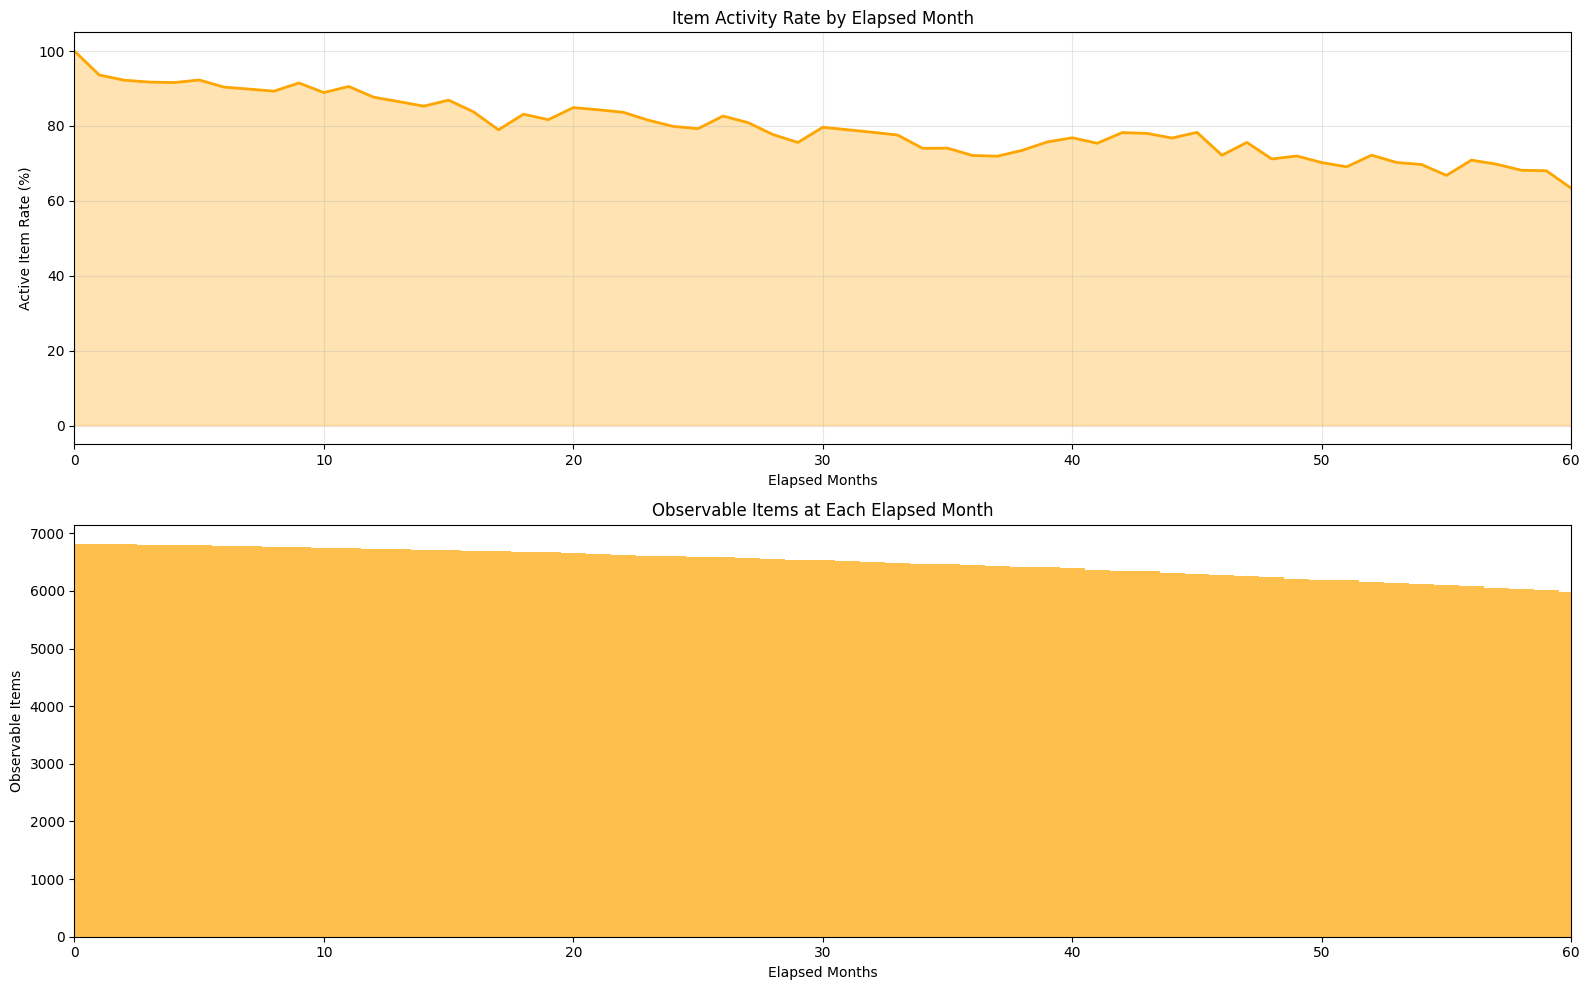

0개월: 100.0% (N=6,807.0)
1개월: 93.6% (N=6,807.0)
3개월: 91.7% (N=6,806.0)
6개월: 90.4% (N=6,781.0)
12개월: 87.7% (N=6,736.0)
24개월: 79.9% (N=6,600.0)
36개월: 72.1% (N=6,447.0)
48개월: 71.2% (N=6,241.0)


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].plot(item_elapsed_df['elapsed_month'], item_elapsed_df['rate'], linewidth=2, color='orange')
axes[0].fill_between(item_elapsed_df['elapsed_month'], item_elapsed_df['rate'], alpha=0.3, color='orange')
axes[0].set_xlim(0, 60)
axes[0].set_xlabel('Elapsed Months')
axes[0].set_ylabel('Active Item Rate (%)')
axes[0].set_title('Item Activity Rate by Elapsed Month')
axes[0].grid(alpha=0.3)

axes[1].bar(item_elapsed_df['elapsed_month'], item_elapsed_df['observable'], alpha=0.7, width=1.0, color='orange')
axes[1].set_xlim(0, 60)
axes[1].set_xlabel('Elapsed Months')
axes[1].set_ylabel('Observable Items')
axes[1].set_title('Observable Items at Each Elapsed Month')
plt.tight_layout()
plt.show()

for m in [0, 1, 3, 6, 12, 24, 36, 48]:
    if m < len(item_elapsed_df):
        r = item_elapsed_df[item_elapsed_df['elapsed_month']==m].iloc[0]
        print(f"{m}개월: {r['rate']:.1f}% (N={r['observable']:,})")

---
## 3. 유저 vs 아이템 비교

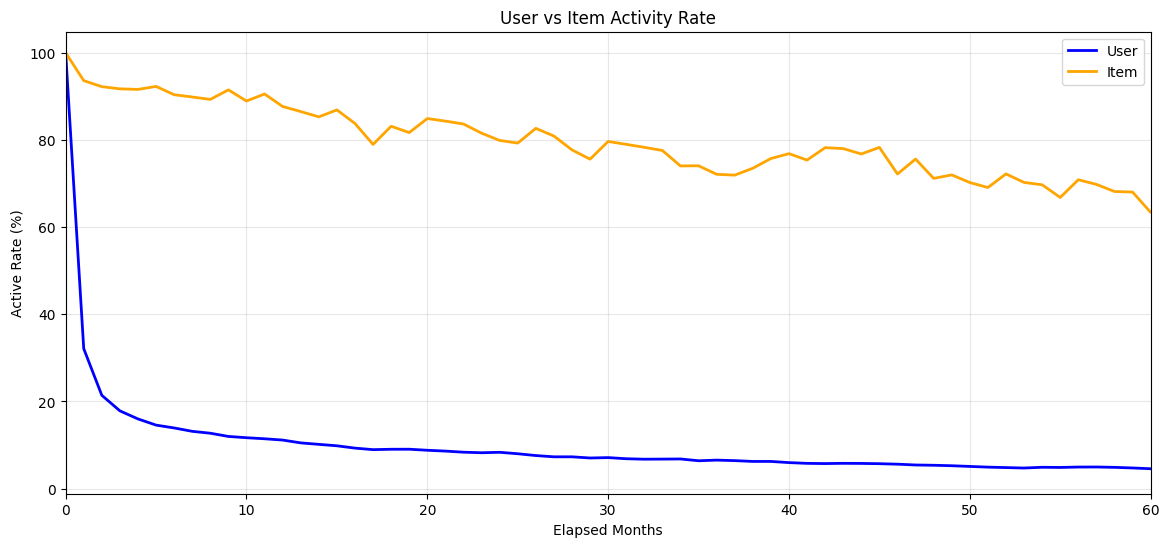

 Month |       User |       Item |     Diff
------------------------------------------
     0 |     100.0% |     100.0% |    +0.0%
     1 |      32.1% |      93.6% |   +61.5%
     3 |      17.8% |      91.7% |   +73.9%
     6 |      13.9% |      90.4% |   +76.4%
    12 |      11.1% |      87.7% |   +76.5%
    24 |       8.3% |      79.9% |   +71.5%
    36 |       6.5% |      72.1% |   +65.6%
    48 |       5.4% |      71.2% |   +65.8%


In [15]:
plt.figure(figsize=(14, 6))
plt.plot(user_elapsed_df['elapsed_month'], user_elapsed_df['rate'], linewidth=2, color='blue', label='User')
plt.plot(item_elapsed_df['elapsed_month'], item_elapsed_df['rate'], linewidth=2, color='orange', label='Item')
plt.xlim(0, 60)
plt.xlabel('Elapsed Months')
plt.ylabel('Active Rate (%)')
plt.title('User vs Item Activity Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"{'Month':>6} | {'User':>10} | {'Item':>10} | {'Diff':>8}")
print("-" * 42)
for m in [0, 1, 3, 6, 12, 24, 36, 48]:
    if m < len(user_elapsed_df) and m < len(item_elapsed_df):
        u = user_elapsed_df[user_elapsed_df['elapsed_month']==m]['rate'].values[0]
        i = item_elapsed_df[item_elapsed_df['elapsed_month']==m]['rate'].values[0]
        print(f"{m:>6} | {u:>9.1f}% | {i:>9.1f}% | {i-u:>+7.1f}%")

---
## 4. 요약

In [16]:
print("="*60)
print("[Step 2-2 요약]")
print("="*60)

print("\n1. 유저 첫 활동 시점")
print(f"   - 첫 3개월: {new_users_monthly.head(3).sum():,}명 ({new_users_monthly.head(3).sum()/len(user_activity)*100:.1f}%) [Left Truncation]")
print(f"   - 이후 월평균: {new_users_monthly.iloc[3:].mean():.0f}명")

print("\n2. 유저 활동 기간")
print(f"   - 평균: {duration_days.mean():.0f}일 ({duration_days.mean()/30:.1f}개월)")
print(f"   - 중앙값: {duration_days.median():.0f}일 ({duration_days.median()/30:.1f}개월)")
print(f"   - 단일 세션: {(duration_days==0).sum()/len(duration_days)*100:.1f}%")

print("\n3. 유저 활성도 추이")
u1 = user_elapsed_df[user_elapsed_df['elapsed_month']==1]['rate'].values[0]
u12 = user_elapsed_df[user_elapsed_df['elapsed_month']==12]['rate'].values[0]
print(f"   - 1개월 후: {u1:.1f}%")
print(f"   - 12개월 후: {u12:.1f}%")

print("\n4. 아이템 최초 상호작용 시점")
print(f"   - 첫 3개월: {new_items_monthly.head(3).sum():,}개 ({new_items_monthly.head(3).sum()/len(item_activity)*100:.1f}%) [Left Truncation]")

print("\n5. 아이템 활성 기간")
print(f"   - 평균: {item_duration_days.mean():.0f}일 ({item_duration_days.mean()/30:.1f}개월)")
print(f"   - 중앙값: {item_duration_days.median():.0f}일 ({item_duration_days.median()/30:.1f}개월)")

print("\n6. 아이템 활성도 추이")
i1 = item_elapsed_df[item_elapsed_df['elapsed_month']==1]['rate'].values[0]
i12 = item_elapsed_df[item_elapsed_df['elapsed_month']==12]['rate'].values[0]
print(f"   - 1개월 후: {i1:.1f}%")
print(f"   - 12개월 후: {i12:.1f}%")

print("\n7. 유저 vs 아이템")
print(f"   - 아이템이 유저보다 장기적으로 활성 상태 유지")
print(f"   - 12개월 후: 유저 {u12:.1f}% vs 아이템 {i12:.1f}%")

[Step 2-2 요약]

1. 유저 첫 활동 시점
   - 첫 3개월: 2,941명 (9.4%) [Left Truncation]
   - 이후 월평균: 243명

2. 유저 활동 기간
   - 평균: 493일 (16.4개월)
   - 중앙값: 20일 (0.7개월)
   - 단일 세션: 35.6%

3. 유저 활성도 추이
   - 1개월 후: 32.1%
   - 12개월 후: 11.1%

4. 아이템 최초 상호작용 시점
   - 첫 3개월: 4,263개 (62.6%) [Left Truncation]

5. 아이템 활성 기간
   - 평균: 3125일 (104.2개월)
   - 중앙값: 3580일 (119.3개월)

6. 아이템 활성도 추이
   - 1개월 후: 93.6%
   - 12개월 후: 87.7%

7. 유저 vs 아이템
   - 아이템이 유저보다 장기적으로 활성 상태 유지
   - 12개월 후: 유저 11.1% vs 아이템 87.7%
